___

# Primitives 


As `primitives` são programas padronizados de alto nível, ou seja, são responsáveis por um conjunto de operações mais simples, facilitando o trabalho do usuário. Um exemplo de primitiva é o próprio `Estimator`, que tem como objetivo encontrar o valor esperado de um operador ou `Sampler` que encontra o estado de output de um circuito, como uma distribuição de probabilidades.


Como input, as primitivas recebem um PUB (Primitive Unified Bloc), que corresponde a um conjunto de circuitos, parametros e shots. Logo isso é entrege diretamente ao Estimator ou Samples que por sua vez utiliza o `Backend` (Statevector, BasicSimulator, AerSimulator, Fake Backend, QPU, Local Simulator) para executar suas operações. 

___

# Qiskit SDK

Para utilizar os primitives temos duas distintas possibilidades além do AerSimulator, o Qiskit SDK e o Qiskit Runtime. Primeiro vamos lidar com o Qiskit SDK (Software Development Kit), que é um pacote *básico* do qiskit, que tem um foco mais geral das primitivas.

Aqui vamos lidar especificamente com o módulo `qiskit.primitives` e as diversas funções e primitivas que oferece, tanto para a versão V1 (deprecated) e V2 (atual):

1. **Base Classes** :

As classes base são as responsáveis por organizar e moldar as primitivas, **são classes para desenvolvimento** e não devem ser utilizados diretamente.

- BaseEstimator 
- BaseSampler 

2. **Backend Primitives**

Essas classes são responsáveis por utilizar as Base Classes em conjunto com um Backend. Essa maneira de utilizar um backend específico com uma Base Class já não é mais utilizado. Um exemplo especifico que utilizamos na seção 3.1 foi o Sampling Estimator (V1) do qiskit Aer, que estava deprecated, portanto utilizamos o BackendEstimatorV1 para poder uitlizar o AerSimulator como Estimator utilizando o BaseEstimatorV1.

- BackendEstimator
- BackendSampler

3. **Primitives** 

Essas são as classes de primitivas que discutimos anteriormente. Elas utilizam a classe [Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector) do `qiskit.quantum_info` para realizar a simulação, o que significa que essas primitivas devem seguir as restrições do StateVector Simulator, com a impossibilidade de rodar um circuito quantico que possui uma medição no meio do circuito.

- Estimator (V1) / StatevectorEstimator (V2)
- Sampler (V1) / StatevectorSampler (V2)


---------------------------‎ 

<div style="display: flex; gap: 2rem;">
<div>

**V1 Primitives**:

- BaseEstimatorV1

- BaseSamplerV1

- ~~BackendEstimatorV1~~ (deprecated)

- ~~BackendSamplerV1~~ (deprecated)

- ~~Estimator~~ (deprecated)

- ~~Sampler~~ (deprecated)

</div>
<div>

**V2 Primitives**:

- BaseEstimatorV2

- BaseSamplerV2

- BackendEstimatorV2

- BackendSamplerV2

- StatevectorEstimator

- StatevectorSampler

</div>
</div>

___

## StatevectorSampler

`qiskit.primitives.StatevectorSampler(*, default_shots=1024, seed=None)`

- default_shots (int) – The default shots for the sampler if not specified during run.
- seed (np.random.Generator | int | None) – The seed or Generator object for random number generation. If None, a random seeded default RNG will be used.

Assim como vimos, o StatevectorSampler é a implementação da primitiva Sampler para o backend V2 do qiskit. Como input do run temos os um conjunto de PUBs, que são compostos pelo circuito, parametros dos gates e shots para o circuito específico. 

> Each tuple of (circuit, <optional> parameter values, <optional> shots), called a sampler primitive unified bloc (PUB), produces its own array-valued result. The `run()` method can be given many pubs at once.

### Métodos 

- .run(pubs, *, shots=None) : Return [PrimitiveJob](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.PrimitiveJob)


In [57]:
import time
import pprint
import warnings
import numpy as np
from tqdm.notebook import tqdm
from math import pi

from qiskit import QuantumCircuit, schedule
from qiskit.circuit import *
from qiskit.primitives import BackendEstimator
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile
from qiskit_aer import *
from qiskit_aer.primitives import Estimator as Aer_EstimatorV1, EstimatorV2 as Aer_EstimatorV2

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

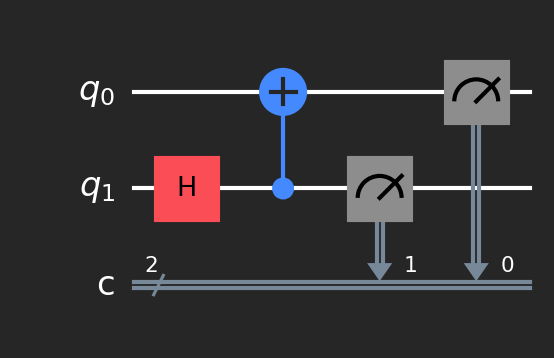

In [7]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.cx(1,0)
qc.measure([1,0],[1,0])
#qc.measure_all()
qc.draw()

In [15]:
simulator = BasicSimulator()
sampler = StatevectorSampler()

job_simulator = simulator.run(qc, shots=1024)
job_sampler = sampler.run([qc], shots=1024)

result_simulator = job_simulator.result()
result_sampler = job_sampler.result()

In [35]:
print(f"Basic Simulator : {result_simulator}")
print("\n-----------\n")
print(f"StatevectorSampler : {result_sampler}\nQuantidade de PUBS : {len(result_sampler)}\nMetadata : {result_sampler.metadata}\nType : {type(result_sampler)}")

Basic Simulator : Result(backend_name='basic_simulator', backend_version='0.1', qobj_id='414c0fb6-a9c9-4256-b166-0b230022fcc7', job_id='561984b3-3c0d-4caf-819c-7b24b4971ddc', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 515, '0x0': 509}), header=QobjExperimentHeader(qubit_labels=[['q', 0], ['q', 1]], n_qubits=2, qreg_sizes=[['q', 2]], clbit_labels=[['c', 0], ['c', 1]], memory_slots=2, creg_sizes=[['c', 2]], name='circuit-166', global_phase=0.0, metadata={}), status=DONE, name='circuit-166', seed_simulator=912072884, time_taken=0.0010449886322021484)], date=None, status=COMPLETED, header=QobjHeader(backend_name='basic_simulator', backend_version='0.1'), time_taken=0.0010526180267333984)

-----------

StatevectorSampler : PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024})], metadata={})
Quantidade de PUBS : 1
Metadata : {}
Type : <class 'q

In [42]:
print(f"SamplerPubResult : {result_sampler[0]}\nMetadata : {result_sampler[0].metadata}\nType : {type(result_sampler[0])}")


SamplerPubResult : SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024})
Metadata : {'shots': 1024}
Type : <class 'qiskit.primitives.containers.sampler_pub_result.SamplerPubResult'>


In [52]:
print(f"DataBin : {result_sampler[0].data}\nType : {type(result_sampler[0].data)}")

DataBin : DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>))
Type : <class 'qiskit.primitives.containers.data_bin.DataBin'>


In [53]:
print(f"Register 'C' : {result_sampler[0].data.c}\nCounts : {result_sampler[0].data.c.get_counts()}")

Register 'C' : BitArray(<shape=(), num_shots=1024, num_bits=2>)
Counts : {'11': 525, '00': 499}


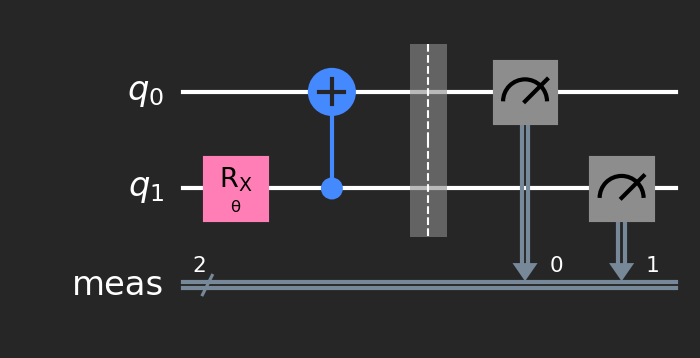

In [56]:
θ = Parameter('θ')

qc2 = QuantumCircuit(2)
qc2.rx(θ, 1)
qc2.cx(1, 0)
qc2.measure_all()
qc2.draw()

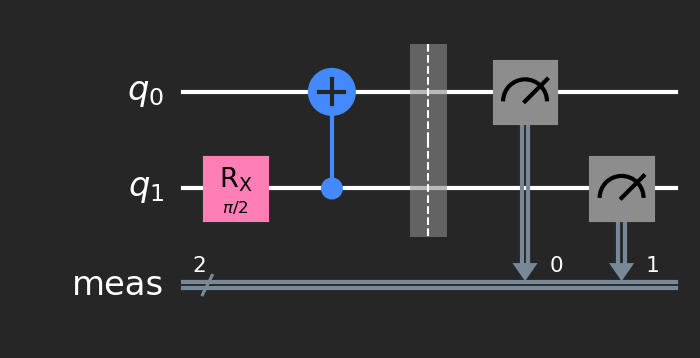

In [59]:
angles = [[pi/4], [pi/3], [pi/2]]

circuits = []
for angle in angles:
    qc_temp = qc2.assign_parameters({θ:angle[0]})
    circuits.append(qc_temp)
    
circuits[2].draw()

In [63]:
circuits_t = transpile(circuits,backend=simulator)
result_simulator = simulator.run(circuits_t, shots=1024).result()

counts_simulator = []

for i, _ in enumerate(angles):
    result_temp = result_simulator.get_counts(i)
    counts_simulator.append(result_temp)
    
print(counts_simulator)

[{'00': 885, '11': 139}, {'00': 767, '11': 257}, {'00': 493, '11': 531}]


In [64]:
result_sampler = sampler.run([(qc2, angles)], shots=1024).result()

counts_sampler = []
for i, _ in enumerate(angles):
    result_temp = result_sampler[0].data.meas.get_counts(i)
    counts_sampler.append(result_temp)
    
print(counts_sampler)


[{'00': 893, '11': 131}, {'00': 769, '11': 255}, {'00': 526, '11': 498}]


In [66]:
print(f".get_counts() shows all results added : {result_sampler[0].data.meas.get_counts()}")

.get_counts() shows all results added : {'00': 2188, '11': 884}


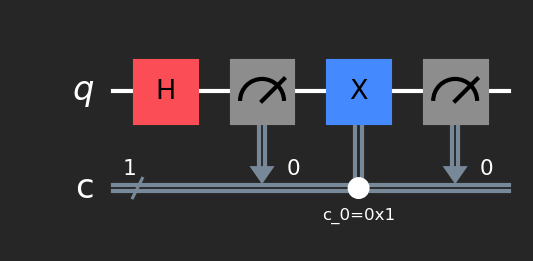

In [67]:
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
qc.x(0).c_if(0,1)
qc.measure(0,0)
qc.draw()

In [71]:

from qiskit.exceptions import QiskitError

try : 
    
    result_sampler = sampler.run([qc], shots=1024).result()
    
    print(f"Rodou")

except QiskitError:
    
    print(f"Error : QiskitError")

Error : QiskitError


> Dado que o StatevectorSampler utiliza o [Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector), ainda temos os mesmos problema de quando utilizamos essa backend, como a impossibilidade de utilizar mid-circuit measurements.  

___

## Statevector Estimator

`qiskit.primitives.StatevectorEstimator(*, default_precision=0.0, seed=None)`

- default_shots (int) – The default shots for the sampler if not specified during run.
- seed (np.random.Generator | int | None) – The seed or Generator object for random number generation. If None, a random seeded default RNG will be used.

Assim como vimos, o StatevectorEstimator é a implementação da primitiva Estimator para o backend V2 do qiskit. Como input do run temos os um conjunto de PUBs, que são compostos pelo circuito, observável, parametros dos gates e shots para o circuito específico. O observável para qual vamos calcular o valor específico é dado por uma `SparsePauliOp`

> Each tuple of (circuit, observables, <optional> parameter values, <optional> precision), called an estimator primitive unified bloc (PUB), produces its own array-based result. The run() method can be given a sequence of pubs to run in one call.

### Métodos 

- .run(pubs, *, shots=None) : Return [PrimitiveJob](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.PrimitiveJob)

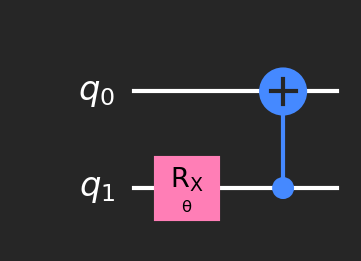

In [73]:
θ = Parameter('θ')

qc2 = QuantumCircuit(2)
qc2.rx(θ, 1)
qc2.cx(1, 0)
#qc2.measure_all()
qc2.draw()

In [74]:
obsv = [[SparsePauliOp(["XX", "IY"], [0.5, 0.5])],
        [SparsePauliOp(["XX"],[1])]]

estimator = StatevectorEstimator()
result_estimator = estimator.run([(qc2, obsv, angles, 0.1)]).result()

result_estimator[0].data.evs

array([[ 0.06853268, -0.14935849, -0.14215324],
       [-0.01244332,  0.07139258, -0.03024126]])

In [76]:
def clifford_qc(num_qubits: int, depth: int):

    qc = QuantumCircuit(num_qubits)

    qc.h(range(num_qubits))

    for level in range(depth):

        for i in range(num_qubits):
        
            if i % 2 == 0:
                qc.s(i)
        
            else:
                qc.sdg(i)
        
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.cx(num_qubits - 1, 0)
    
    #qc.measure_all()

    return qc

def expectation_value_total(num_qubits, depth, shots):
    
    results = {}
    
    qc = clifford_qc(num_qubits, depth)
    
    observable = SparsePauliOp.from_list([("".join(['I']*(n_qubits-1-i) + ['Z'] + ['I']*i), 1.0) for i in range(n_qubits)])
    
    start_time = time.time()
    estimator_sampling = Aer_EstimatorV1(approximation = False)
    result = estimator_sampling.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Sampling Estimator Aer"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_normal = Aer_EstimatorV1(approximation = True)
    result = estimator_normal.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Normal Estimator Aer"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_exact = Aer_EstimatorV1(approximation = True)
    result = estimator_exact.run(qc, observable, shots = None).result()
    end_time = time.time()
    results["Exact Estimator Aer"] = [result.values[0], end_time - start_time] 

    start_time = time.time()
    estimator_backendestimator = BackendEstimator(backend = AerSimulator())
    result = estimator_backendestimator.run(qc, observable, shots=shots).result()
    end_time = time.time()
    results["BackendEstimator Aer"] = [result.values[0], end_time - start_time]
    
    start_time = time.time()
    options_sampling_v2 = {"run_options": {"shots": shots}}
    estimator_v2_sampling = Aer_EstimatorV2(options=options_sampling_v2)
    result = estimator_v2_sampling.run([(qc, observable)], precision=0.01).result()
    end_time = time.time()
    results["Sampling EstimatorV2 Aer"] = [result[0].data.evs, end_time - start_time]

    start_time = time.time()
    estimator_v2_exact = Aer_EstimatorV2()
    result = estimator_v2_exact.run([(qc, observable)], precision=0.0).result()
    end_time = time.time()
    results["Exact EstimatorV2 Aer"] = [result[0].data.evs, end_time - start_time]

    start_time = time.time()
    estimator_qiskit_exact = StatevectorEstimator()
    result = estimator_qiskit_exact.run([(qc, observable)]).result()
    end_time = time.time()
    results["Exact EstimatorV2 Qiskit"] = [result[0].data.evs, end_time - start_time]

    start_time = time.time()
    estimator_qiskit_sampler = StatevectorEstimator()
    result = estimator_qiskit_sampler.run([(qc, observable)], precision = 0.1).result()
    end_time = time.time()
    results["Sampling EstimatorV2 Qiskit"] = [result[0].data.evs, end_time - start_time]
    
    return results

qubit_range, depth = range(2, 16), 15
shots = 1024
iterations = 100

method_names = [
    "Sampling Estimator Aer",
    "Normal Estimator Aer",
    "Exact Estimator Aer",
    "BackendEstimator Aer",
    "Sampling EstimatorV2 Aer",
    "Exact EstimatorV2 Aer",
    "Exact EstimatorV2 Qiskit",
    "Sampling EstimatorV2 Qiskit"
]

times = {name: [] for name in method_names}
values = {name: [] for name in method_names}

warnings.filterwarnings('ignore', category=DeprecationWarning)

for n_qubits in qubit_range:

    temp_times = {name: [] for name in method_names}
    temp_values = {name: [] for name in method_names}

    for a in range(iterations):
        
        result = expectation_value_total(num_qubits=n_qubits, depth=depth, shots=shots)
        
        temp_times["Sampling Estimator Aer"].append(result["Sampling Estimator Aer"][1])
        temp_values["Sampling Estimator Aer"].append(result["Sampling Estimator Aer"][0])
     
        temp_times["Normal Estimator Aer"].append(result["Normal Estimator Aer"][1])
        temp_values["Normal Estimator Aer"].append(result["Normal Estimator Aer"][0])

        temp_times["Exact Estimator Aer"].append(result["Exact Estimator Aer"][1])
        temp_values["Exact Estimator Aer"].append(result["Exact Estimator Aer"][0])

        temp_times["BackendEstimator Aer"].append(result["BackendEstimator Aer"][1])
        temp_values["BackendEstimator Aer"].append(result["BackendEstimator Aer"][0])

        temp_times["Sampling EstimatorV2 Aer"].append(result["Sampling EstimatorV2 Aer"][1])
        temp_values["Sampling EstimatorV2 Aer"].append(result["Sampling EstimatorV2 Aer"][0])

        temp_times["Exact EstimatorV2 Aer"].append(result["Exact EstimatorV2 Aer"][1])
        temp_values["Exact EstimatorV2 Aer"].append(result["Exact EstimatorV2 Aer"][0])

        temp_times["Exact EstimatorV2 Qiskit"].append(result["Exact EstimatorV2 Qiskit"][1])
        temp_values["Exact EstimatorV2 Qiskit"].append(result["Exact EstimatorV2 Qiskit"][0])

        temp_times["Sampling EstimatorV2 Qiskit"].append(result["Sampling EstimatorV2 Qiskit"][1])
        temp_values["Sampling EstimatorV2 Qiskit"].append(result["Sampling EstimatorV2 Qiskit"][0])

    for name in method_names:
        times[name].append(np.mean(temp_times[name]))
        values[name].append(np.mean(temp_values[name]))

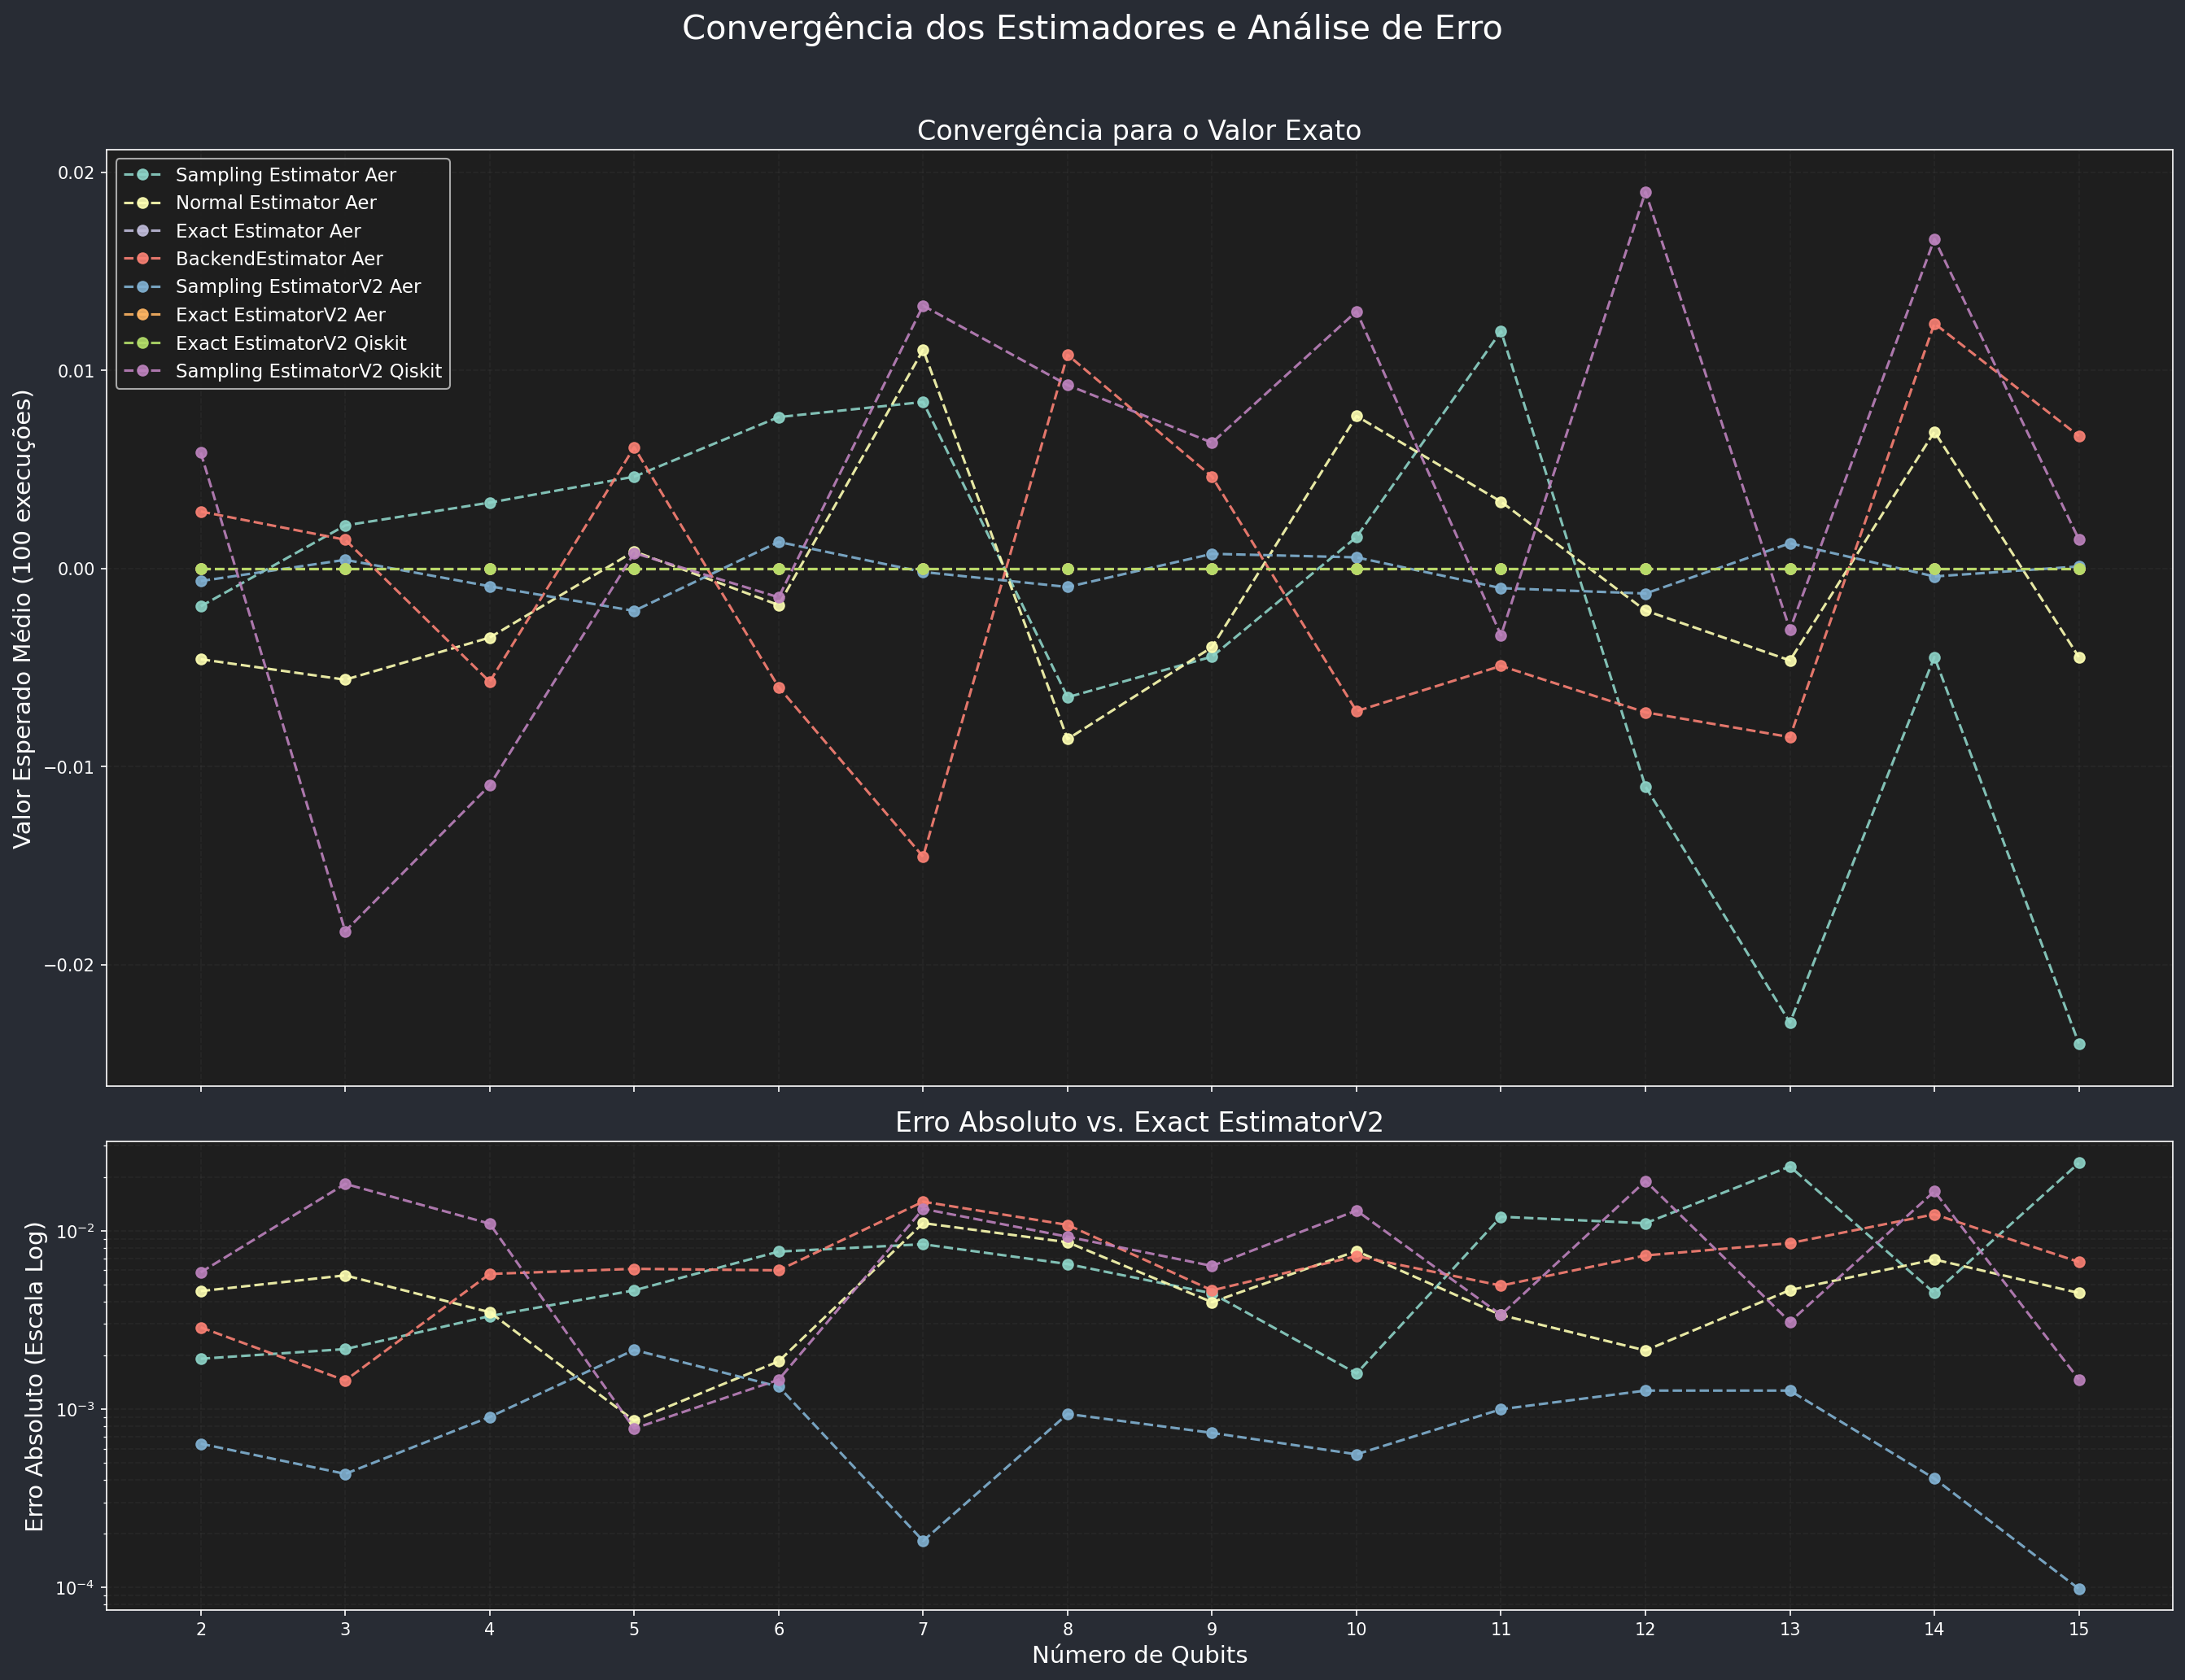

In [78]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

color_map = {name: color for name, color in zip(method_names, colors)}

exact_values_baseline = values["Exact EstimatorV2 Aer"]

errors = {}
error_method_names = [name for name in method_names if "Exact" not in name]
for name in error_method_names:
    errors[name] = np.abs(np.array(values[name]) - np.array(exact_values_baseline))

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(18, 14), 
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)
fig.suptitle("Convergência dos Estimadores e Análise de Erro", fontsize=20)

ax1.set_title("Convergência para o Valor Exato", fontsize=16)
for name in method_names:
    ax1.plot(qubit_range, values[name], 
             "o--",
             label=name, 
             alpha=0.9,
             color=color_map[name])

ax1.set_ylabel(f"Valor Esperado Médio ({iterations} execuções)", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.25)

ax2.set_title("Erro Absoluto vs. Exact EstimatorV2", fontsize=16)
for name in error_method_names:
    ax2.plot(qubit_range, errors[name], 
             "o--",
             color=color_map[name],
             alpha=0.9)

ax2.set_xlabel("Número de Qubits", fontsize=14)
ax2.set_ylabel("Erro Absoluto (Escala Log)", fontsize=14)
ax2.set_xticks(qubit_range)
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--", alpha=0.25)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

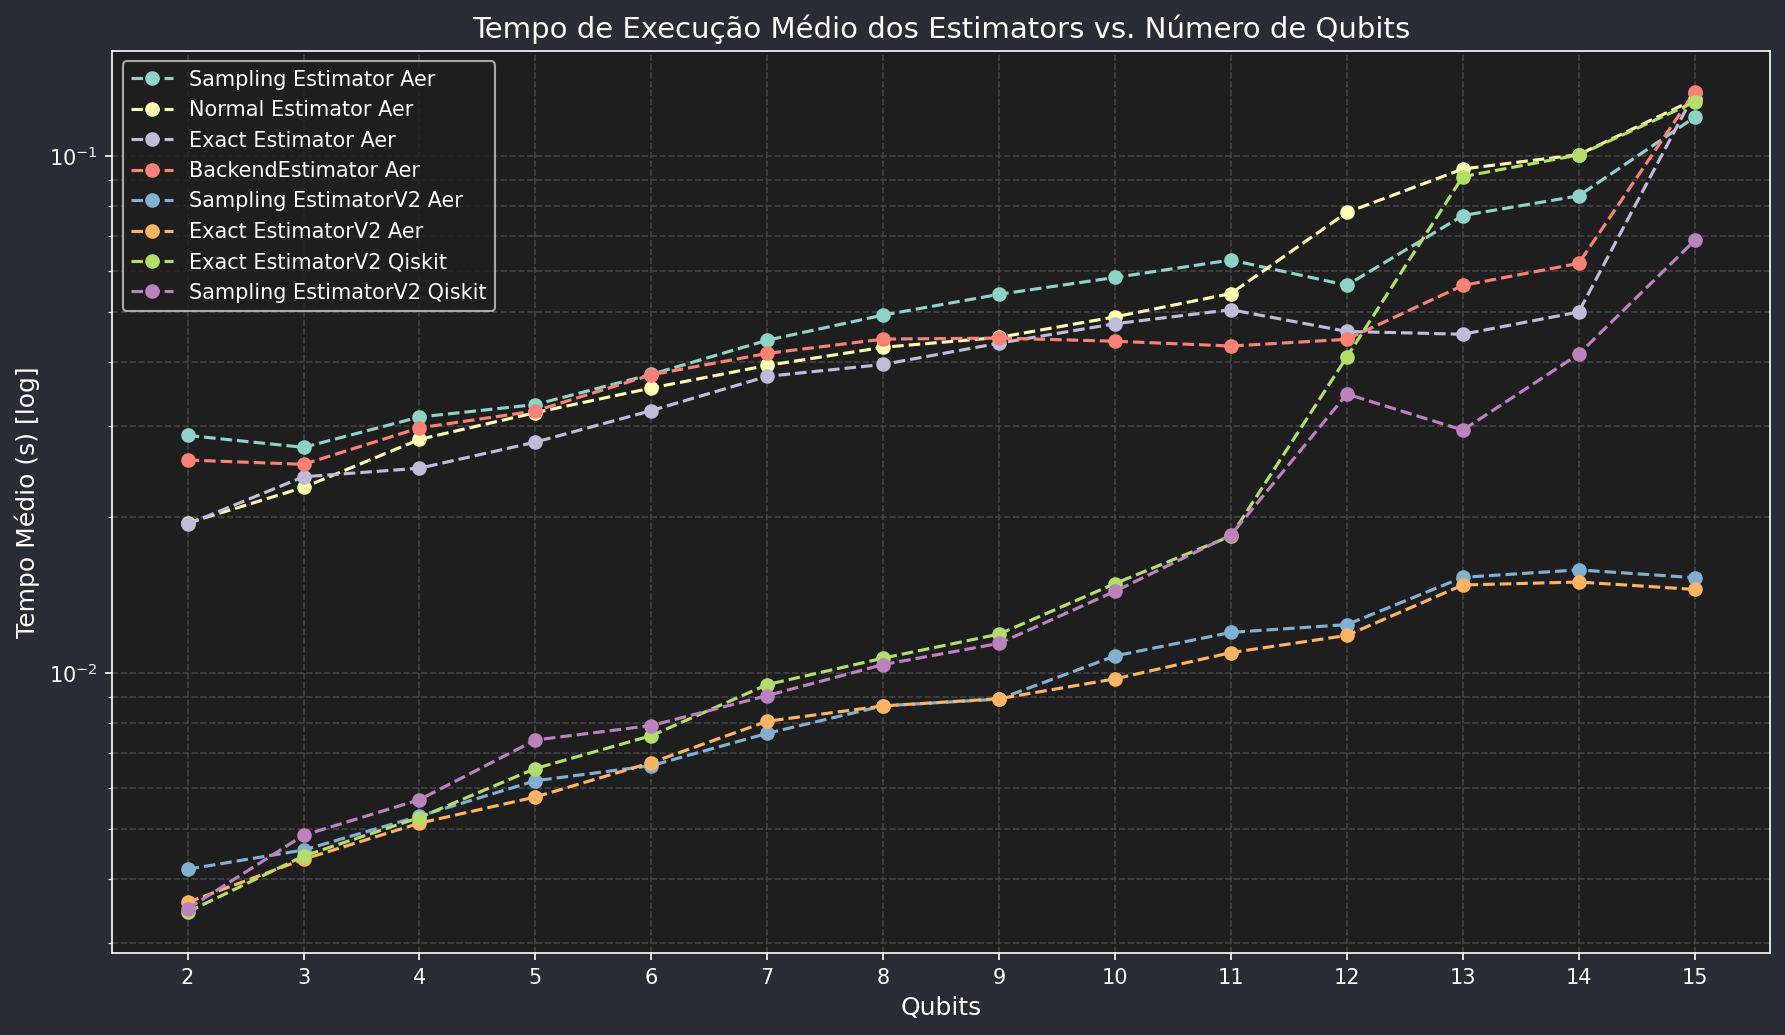

In [79]:
plt.figure(figsize=(12, 7))
for i, name in enumerate(method_names):
     plt.plot(qubit_range, times[name], "o--", label=name)

plt.xlabel("Qubits", fontsize=12)
plt.ylabel("Tempo Médio (s) [log]", fontsize=12)
plt.title("Tempo de Execução Médio dos Estimators vs. Número de Qubits", fontsize=14)
plt.yscale('log')
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Com esse gráfico podemos ver que o StatevectorEstimator é um pouco mais preciso e mais eficiente que o EstimatorV1 do Aer, porem muito pior que o EstimatorV2. Sendo assim, a escolha do Sampling EstimatorV2 do Aer segue sendo a melhor opção para encontrar o valor esperando, ainda considerando que essa não tem os impedimentos que o Statevector traz. 